<a href="https://colab.research.google.com/github/SandAhmed/Team-Megaforce-Ai-project/blob/Model3/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv('/train_data.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/train_data.csv'

In [ ]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
299,LP001367,Male,Yes,1,Graduate,No,3052,1030.0,100.0,360.0,1.0,Urban,Y
300,LP001606,Male,Yes,0,Graduate,No,3497,1964.0,116.0,360.0,1.0,Rural,Y
301,LP002366,Male,Yes,0,Graduate,No,2666,4300.0,121.0,360.0,1.0,Rural,Y
302,LP002777,Male,Yes,0,Graduate,No,2785,2016.0,110.0,360.0,1.0,Rural,Y
303,LP001579,Male,No,0,Graduate,No,2237,0.0,63.0,480.0,0.0,Semiurban,N


In [ ]:
print(df['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
Y    0.707237
N    0.292763
Name: proportion, dtype: float64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.dtypes)

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [ ]:
le = LabelEncoder()
categ_cols = [ 'Gender','Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categ_cols:
  df[col] = le.fit_transform(df[col])

print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object


In [ ]:
#null values percentage
df.isna().sum()/len(df)*100

,0
Loan_ID,0.000000
Gender,0.000000
Married,0.000000
Dependents,2.302632
Education,0.000000
Self_Employed,0.000000
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,0.000000
Loan_Amount_Term,2.960526


In [ ]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_6142/3390244665.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
/tmp/ipykernel_6142/3390244665.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
df['Loan_Amount_Term']=df["Loan_Amount_Term"].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            304 non-null    int64  
 1   Gender             304 non-null    int64  
 2   Married            304 non-null    int64  
 3   Dependents         304 non-null    object 
 4   Education          304 non-null    int64  
 5   Self_Employed      304 non-null    int64  
 6   ApplicantIncome    304 non-null    int64  
 7   CoapplicantIncome  304 non-null    float64
 8   LoanAmount         304 non-null    float64
 9   Loan_Amount_Term   304 non-null    float64
 10  Credit_History     304 non-null    float64
 11  Property_Area      304 non-null    int64  
 12  Loan_Status        304 non-null    int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 31.0+ KB


In [ ]:
df.describe()

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,304.00000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,151.50000,0.792763,0.605263,0.269737,0.194079,3583.828947,1220.645132,105.282895,342.631579,0.835526,1.036184,0.707237
std,87.90146,0.429690,0.489600,0.444555,0.518787,1366.102888,1732.098606,28.696412,66.256595,0.371316,0.780543,0.455781
min,0.00000,0.000000,0.000000,0.000000,0.000000,210.000000,0.000000,17.000000,12.000000,0.000000,0.000000,0.000000
25%,75.75000,1.000000,0.000000,0.000000,0.000000,2651.000000,0.000000,90.000000,360.000000,1.000000,0.000000,0.000000
50%,151.50000,1.000000,1.000000,0.000000,0.000000,3365.500000,953.000000,110.500000,360.000000,1.000000,1.000000,1.000000
75%,227.25000,1.000000,1.000000,1.000000,0.000000,4284.250000,2045.000000,128.000000,360.000000,1.000000,2.000000,1.000000
max,303.00000,2.000000,1.000000,1.000000,2.000000,9703.000000,20000.000000,150.000000,480.000000,1.000000,2.000000,1.000000


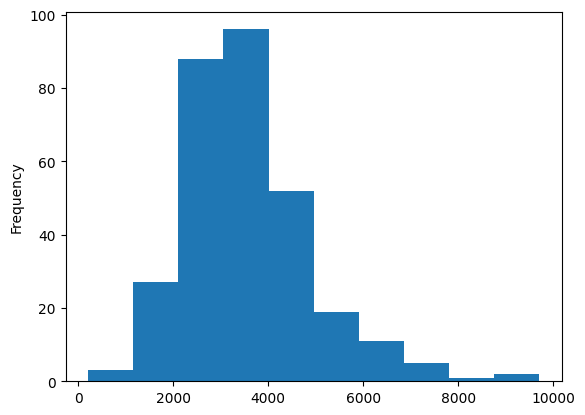

In [ ]:
plt.hist(df['ApplicantIncome'])
plt.ylabel("Frequency")
plt.show()

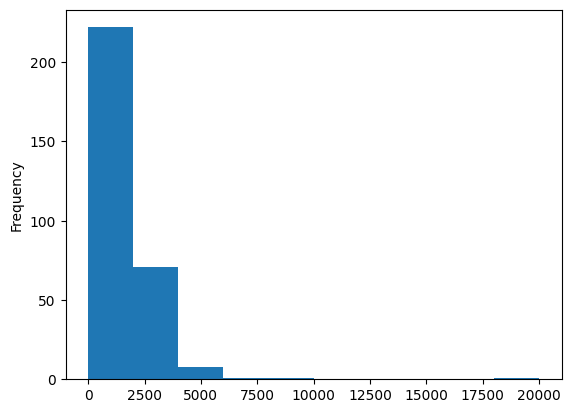

In [ ]:
plt.hist(df['CoapplicantIncome'])
plt.ylabel("Frequency")
plt.show()

In [ ]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

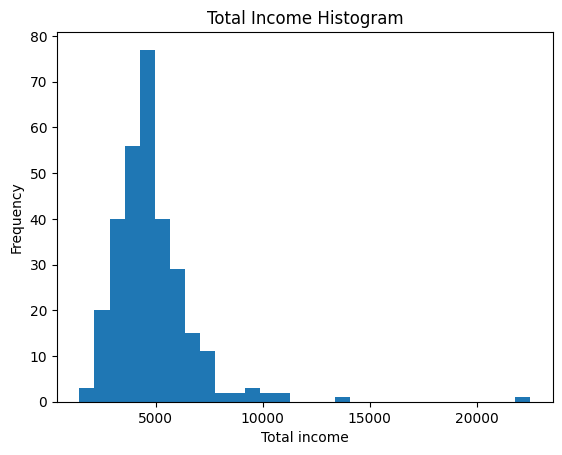

In [ ]:
plt.hist(df['TotalIncome'], bins=30)
plt.title("Total Income Histogram")
plt.xlabel("Total income")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


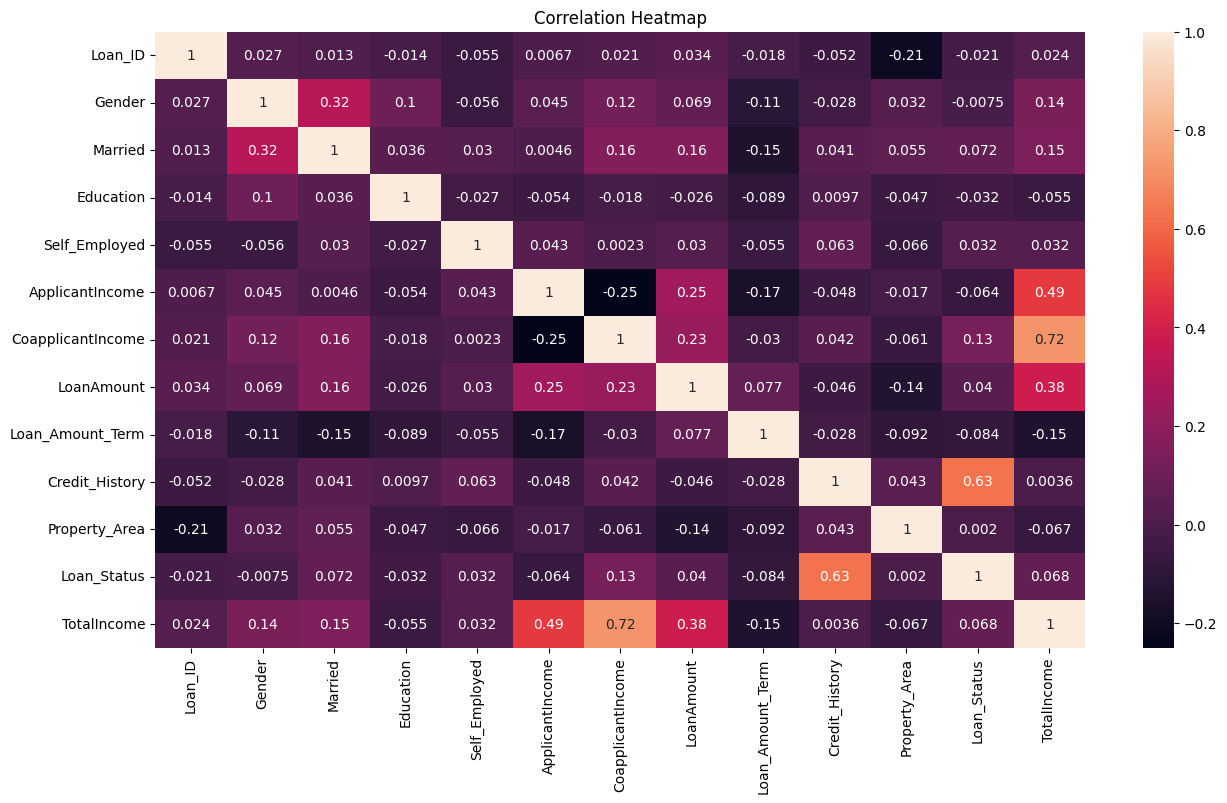

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
#dropped because the correlation coofecient between it and the loan status is low
#df = df.drop('Gender', axis = 1, errors = 'ignore')

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,55,0,0,0,0,0,4166,0.0,44.0,360.0,1.0,1,1,4166.0
1,209,1,1,0,0,0,3246,1417.0,138.0,360.0,1.0,1,1,4663.0
2,67,1,0,0,0,0,6277,0.0,118.0,360.0,0.0,0,0,6277.0
3,300,1,1,0,0,0,3232,1950.0,108.0,360.0,1.0,0,1,5182.0
4,215,1,1,2,0,0,5935,0.0,133.0,360.0,1.0,1,1,5935.0


In [ ]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
299,52,1,1,1,0,0,3052,1030.0,100.0,360.0,1.0,2,1,4082.0
300,77,1,1,0,0,0,3497,1964.0,116.0,360.0,1.0,0,1,5461.0
301,213,1,1,0,0,0,2666,4300.0,121.0,360.0,1.0,0,1,6966.0
302,281,1,1,0,0,0,2785,2016.0,110.0,360.0,1.0,0,1,4801.0
303,74,1,0,0,0,0,2237,0.0,63.0,480.0,0.0,1,0,2237.0


In [ ]:
features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term', 'TotalIncome', 'CoapplicantIncome']

In [ ]:
#null values percentage
df.isna().sum()/len(df)*100

,0
Loan_ID,0.0
Gender,0.0
Married,0.0
Dependents,0.0
Education,0.0
Self_Employed,0.0
ApplicantIncome,0.0
CoapplicantIncome,0.0
LoanAmount,0.0
Loan_Amount_Term,0.0


In [ ]:
x = df[features]
y = df['Loan_Status']

In [ ]:
df['Dependents'] = df['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)

In [ ]:
print(df.dtypes)

Loan_ID                int64
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


In [ ]:
model = GradientBoostingClassifier(n_estimators=50, learning_rate=0.05, max_depth=1)
model.fit(x, y)

GradientBoostingClassifier(learning_rate=0.05, max_depth=1, n_estimators=50)

In [ ]:
tdf = pd.read_csv("/content/test_data.csv")
tdf['TotalIncome'] = tdf['ApplicantIncome'] + tdf['CoapplicantIncome']
le = LabelEncoder()
categ_cols = [ 'Gender','Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']


tdf['Dependents'].fillna(tdf['Dependents'].mode()[0], inplace=True)
tdf['Gender'].fillna(tdf['Gender'].mode()[0], inplace=True)
tdf['Self_Employed'].fillna(tdf['Self_Employed'].mode()[0], inplace=True)

tdf['Loan_Amount_Term']=tdf["Loan_Amount_Term"].fillna(tdf['Loan_Amount_Term'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())
tdf['Credit_History']=tdf["Credit_History"].fillna(tdf['Credit_History'].median())

for col in categ_cols:
  tdf[col] = le.fit_transform(tdf[col])

tdf['Dependents'] = tdf['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
tdf['Dependents'] = pd.to_numeric(tdf['Dependents'], errors='coerce').fillna(0).astype(int)
print(tdf.dtypes)
x_test = tdf[features]
y_test = tdf['Loan_Status']

Loan_ID                int64
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


/tmp/ipykernel_6142/221794456.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tdf['Dependents'].fillna(tdf['Dependents'].mode()[0], inplace=True)
/tmp/ipykernel_6142/221794456.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
predictions = model.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

Model Accuracy: 0.8181818181818182


In [ ]:
predictions = model.predict(x)
print(f"Model Accuracy: {accuracy_score(y, predictions)}")

Model Accuracy: 0.8519736842105263


In [ ]:
print(tdf['Loan_Status'].value_counts(normalize = 'true'))

Loan_Status
Y    0.727273
N    0.272727
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, x, y, cv=5)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.83606557 0.86885246 0.8852459  0.81967213 0.85      ]
Average Accuracy: 0.8519672131147541
Standard Deviation: 0.02320468495635473


In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = model.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.8993


In [ ]:
y_probs = model.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc: .4f}")

AUC Score:  0.8081


In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report
y_pred = rf.predict(x_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.8800


In [ ]:
predictions = rf.predict(x_test)
print(f"Model Accuracy: {accuracy_score(y_test, predictions)}")

Model Accuracy: 0.8051948051948052


In [ ]:
predictions = rf.predict(x_train)
print(f"Model Accuracy: {accuracy_score(y_train, predictions)}")

Model Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

# This will show you exactly where the 0.8966 is coming from
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.48      0.65        25
           1       0.84      1.00      0.91        67

    accuracy                           0.86        92
   macro avg       0.92      0.74      0.78        92
weighted avg       0.88      0.86      0.84        92

